In [179]:
from neural_priors.utils.data import Subject
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.odr import ODR, Model, RealData
import os
from pathlib import Path

sns.set_context('poster')

In [180]:
bids_folder = Path('/data/ds-neuralpriors')
fig_folder = bids_folder / 'derivatives' / 'figures' / 'figure_dispersion_shift'
os.makedirs(fig_folder, exist_ok=True)

In [ ]:
bids_folder = Path('/data/ds-neuralpriors')
# pars = pd.read_csv(bids_folder / 'derivatives' / 'encoding_models' / 'group_roi-NPCr_desc-groundtruth_parameters.tsv', sep='\t', index_col=[0, 1, 2, 3], header=[0, 1, ])
pars = pd.read_csv(bids_folder / 'derivatives' / 'encoding_models 'group_roi-NPCr_desc-groundtruth_parameters.tsv', sep='\t', index_col=[0, 1, 2, 3], header=[0, 1, ])
pars.index.set_names('subject', level='subject_id', inplace=True)
cvr2_mask = pars[pars[('cvr2', 'nan')] > 0.0]

In [ ]:
model_sd_fixed = pars.xs(4, level='model_label', )
model_sd_voxel_free = pars.xs(14, level='model_label', )
model_sd_slope_fixed = pars.xs(15, level='model_label')
model_sd_slope_fixed_sqrt2 = pars.xs(25, level='model_label')
model_sd_voxel_free_natural = pars.xs(26, level='model_label', )
model_sd_voxel_fixed2_natural = pars.xs(27, level='model_label', )
model_fwhm_free_slope = pars.xs(28, level='model_label', )
model_fwhm_slope_fixed2 = pars.xs(29, level='model_label', )
model_fwhm_voxel_free = pars.xs(30, level='model_label', )
model_sd_slope_fixed_average_subjects = pars.xs(31, level='model_label', )

In [165]:
(model_sd_slope_fixed[('sd', 'wide')] / model_sd_slope_fixed[('sd', 'narrow')]).groupby('subject').mean().describe()

count    39.000000
mean      1.287794
std       0.248585
min       0.745288
25%       1.152647
50%       1.309340
75%       1.461959
max       1.722680
dtype: float64

<Axes: xlabel='sigma_log (narrow)', ylabel='FWHM (narrow)'>

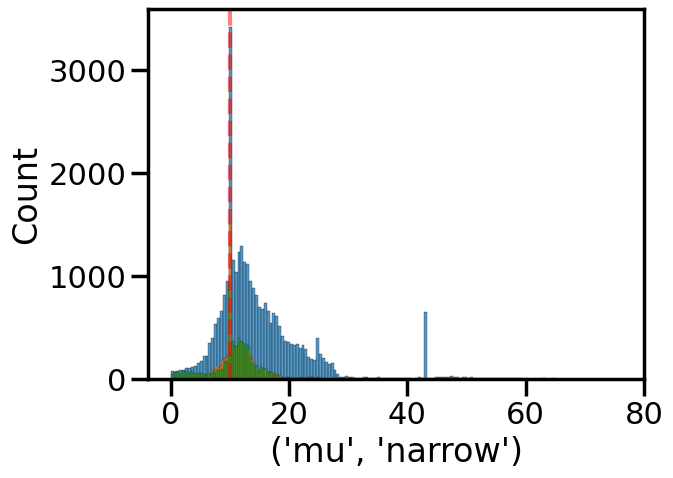

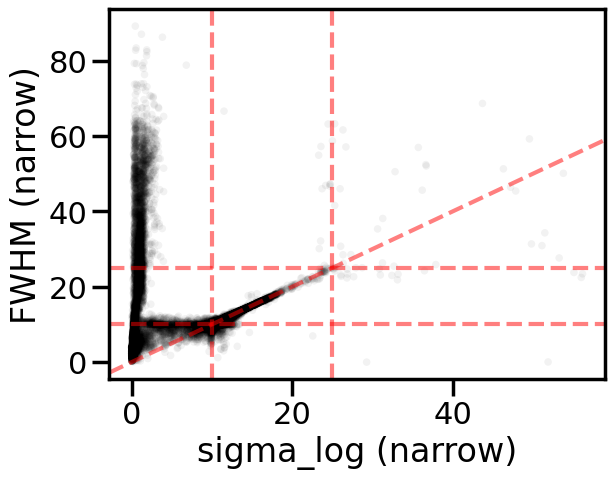

In [166]:
cvr21 = model_fwhm_slope_fixed2[('cvr2', 'nan')]
sns.histplot(model_fwhm_slope_fixed2[('mu', 'narrow')])
sns.histplot(model_fwhm_slope_fixed2.loc[cvr21> 0.0, ('mu', 'narrow')])

cvr22 = model_sd_voxel_free[('cvr2', 'nan')]
sns.histplot(model_sd_voxel_free.loc[cvr22> 0.0, ('mu', 'narrow')])

plt.axvline(10., c='red', linestyle='--', alpha=.5)

plt.figure()
sns.scatterplot(x=model_sd_voxel_free.loc[cvr22 > 0.0, ('mu', 'narrow')],
                y=model_fwhm_slope_fixed2.loc[cvr21 > 0.0, ('mu', 'narrow')], c='k', edgecolor='none', s=30, alpha=.05)

plt.xlabel('sigma_log (narrow)')
plt.ylabel('FWHM (narrow)')

plt.axvline(10., c='red', linestyle='--', alpha=.5)
plt.axhline(10., c='red', linestyle='--', alpha=.5)
plt.axhline(25, c='red', linestyle='--', alpha=.5)
plt.axvline(25, c='red', linestyle='--', alpha=.5)
plt.axline((0, 0), slope=1., c='red', alpha=.5, linestyle='--')


sns.scatterplot(x=model_sd_voxel_free.loc[cvr22 > 0.0, ('sd', 'narrow')],
                y=model_fwhm_slope_fixed2.loc[cvr21 > 0.0, ('sd', 'narrow')], c='k', edgecolor='none', s=30, alpha=.05)

In [167]:
model_fwhm_free_slope[('sd', 'wide')] / model_fwhm_free_slope[('sd', 'narrow')]

subject  smoothed     
1        True      0      1.308078
                   1      1.308078
                   2      1.308078
                   3      1.308078
                   4      1.308078
                            ...   
41       True      689    1.763115
                   690    1.763115
                   691    1.763115
                   692    1.763115
                   693    1.763115
Length: 30533, dtype: float64

(0.0, 30.0)

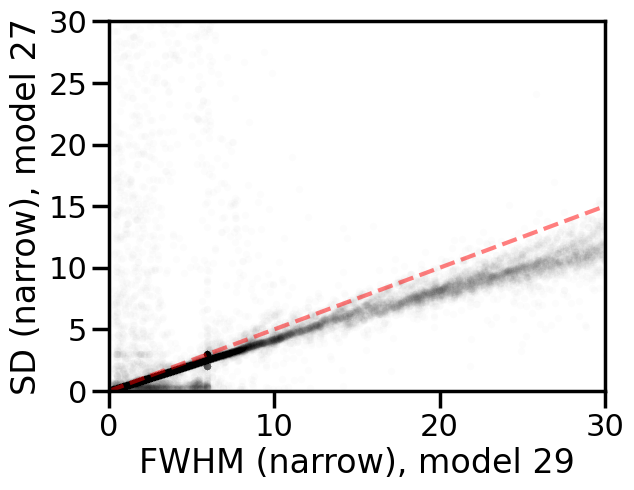

In [168]:
sns.scatterplot(x=model_fwhm_slope_fixed2[('sd', 'narrow')], y=model_sd_voxel_fixed2_natural[('sd', 'narrow')],
alpha=.01, s=30, color='black')

# plot identity line
# x = np.linspace(0, 20, 100)
# y = x
# plt.plot(x, y, color='red', linestyle='--')
# plt.xlabel('FWHM (narrow)')
# plt.ylabel('SD (narrow)')

plt.axline((0,0), slope=1/2., c='red', alpha=.5, linestyle='--')


plt.xlabel('FWHM (narrow), model 29')
plt.ylabel('SD (narrow), model 27')

plt.xlim(0, 30)
plt.ylim(0, 30)

<Axes: xlabel="('sd', 'narrow')", ylabel='Count'>

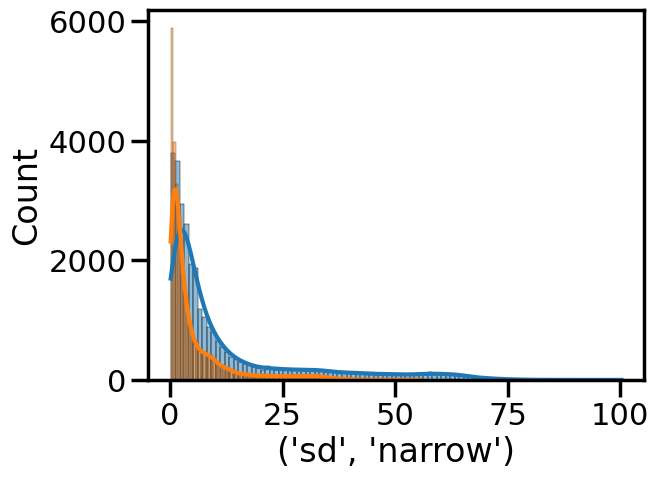

In [169]:
sns.histplot(model_fwhm_free_slope[('sd', 'narrow')], bins=100, kde=True)
sns.histplot(model_sd_voxel_free_natural[('sd', 'narrow')], bins=100, kde=True)

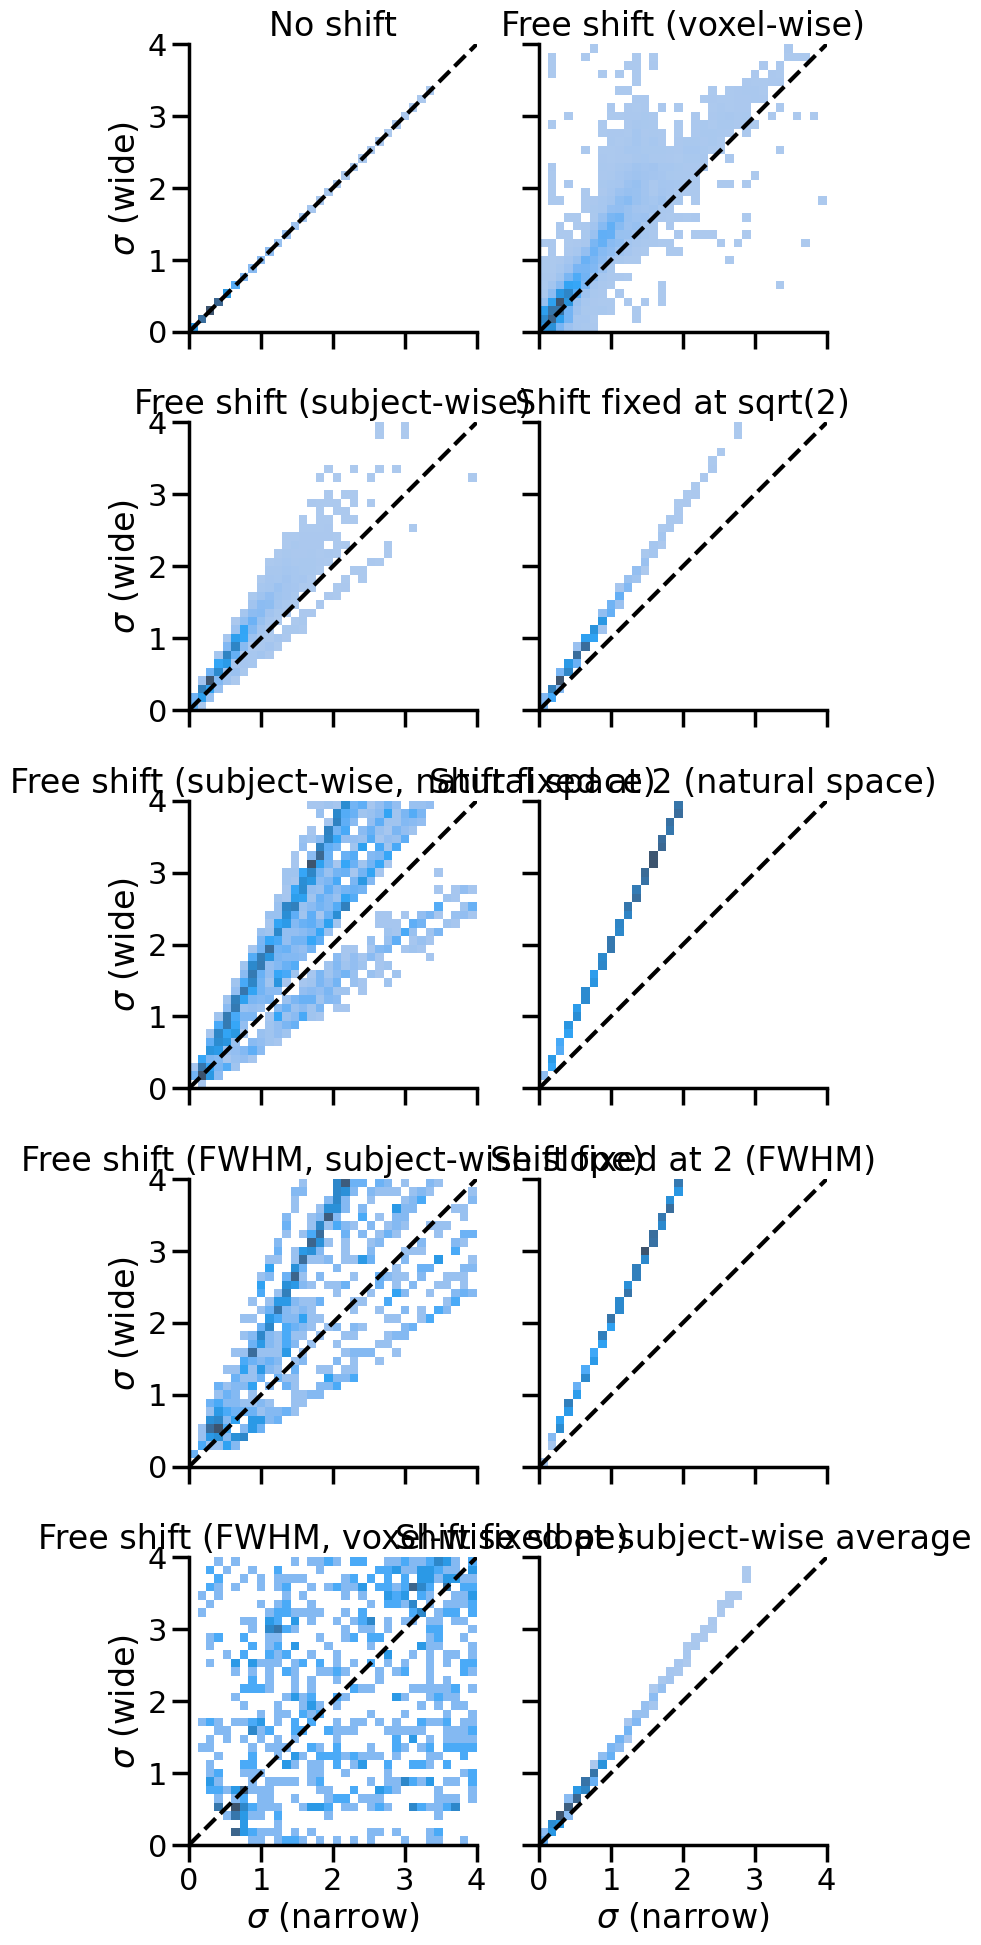

In [170]:
max_dispersion = 4

max_dispersion_natural = 30

pars = pd.concat((model_sd_fixed, model_sd_voxel_free, model_sd_slope_fixed, model_sd_slope_fixed_sqrt2,
                  model_sd_voxel_free_natural, model_sd_voxel_fixed2_natural,
                  model_fwhm_free_slope, model_fwhm_slope_fixed2, model_fwhm_voxel_free,
                  model_sd_slope_fixed_average_subjects),
                  axis=0, keys=['No shift', 'Free shift (voxel-wise)', 'Free shift (subject-wise)',
                                                                                            'Shift fixed at sqrt(2)',
                                                                                            'Free shift (subject-wise, natural space)',
                                                                                            'Shift fixed at 2 (natural space)',
                                                                                            'Free shift (FWHM, subject-wise slope)',
                                                                                            'Shift fixed at 2 (FWHM)',
                                                                                            'Free shift (FWHM, voxel-wise slope)',
                                                                                            'Shift fixed at subject-wise average'],
                                                                                             names=['model_label'])

pars_ = pars[pars[('cvr2', 'nan')] > 0.0]

g = sns.FacetGrid(pars_['sd'].reset_index(), col='model_label', col_wrap=2, height=4, aspect=1.)

g.map_dataframe(sns.histplot, x='narrow', y='wide', bins=[np.linspace(0, max_dispersion, 35), np.linspace(0, max_dispersion, 35)],)

g.set(xlim=(0, max_dispersion), ylim=(0, max_dispersion), xlabel='Narrow', ylabel='Wide')

g.set(xticks=np.arange(0, max_dispersion+1), yticks=np.arange(0, max_dispersion+1))
g.set_titles('{col_name}')

g.set_xlabels('$\sigma$ (narrow)')
g.set_ylabels('$\sigma$ (wide)')


# plot identity line
g.map(plt.axline, xy1=(0, 0), slope=1, color='k', linestyle='--')

plt.tight_layout()


# Make sure all axes are square
for ax in g.axes.flat:
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(0, max_dispersion)
    ax.set_ylim(0, max_dispersion)




g.savefig(fig_folder / 'dispersion_shift_hist.pdf', bbox_inches='tight')

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,hedges
0,model_label,"Free shift (FWHM, subject-wise slope)","Free shift (FWHM, voxel-wise slope)",True,True,3.218721,38.0,two-sided,2.635427e-03,13.064,0.066962
1,model_label,"Free shift (FWHM, subject-wise slope)",Free shift (subject-wise),True,True,-4.229826,38.0,two-sided,1.419636e-04,177.967,-0.134840
2,model_label,"Free shift (FWHM, subject-wise slope)","Free shift (subject-wise, natural space)",True,True,-0.362402,38.0,two-sided,7.190595e-01,0.184,-0.004298
3,model_label,"Free shift (FWHM, subject-wise slope)",Free shift (voxel-wise),True,True,0.493603,38.0,two-sided,6.244274e-01,0.193,0.014245
4,model_label,"Free shift (FWHM, subject-wise slope)",No shift,True,True,-4.037064,38.0,two-sided,2.529417e-04,105.514,-0.113827
5,model_label,"Free shift (FWHM, subject-wise slope)",Shift fixed at 2 (FWHM),True,True,-2.263143,38.0,two-sided,2.942297e-02,1.663,-0.049711
6,model_label,"Free shift (FWHM, subject-wise slope)",Shift fixed at 2 (natural space),True,True,-2.646983,38.0,two-sided,1.175436e-02,3.585,-0.058623
7,model_label,"Free shift (FWHM, subject-wise slope)",Shift fixed at sqrt(2),True,True,-5.666943,38.0,two-sided,1.630287e-06,1.084e+04,-0.187643
8,model_label,"Free shift (FWHM, subject-wise slope)",Shift fixed at subject-wise average,True,True,-6.632937,38.0,two-sided,7.749668e-08,1.871e+05,-0.207950
9,model_label,"Free shift (FWHM, voxel-wise slope)",Free shift (subject-wise),True,True,-5.674513,38.0,two-sided,1.591776e-06,1.108e+04,-0.201055


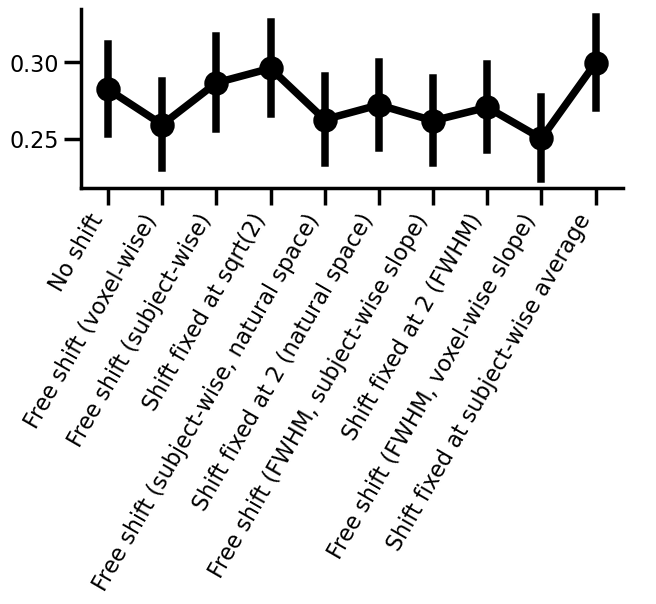

In [172]:
import pingouin as pg
prop_cvr2 = pars.groupby(['model_label', 'subject']).apply(lambda d: (d[('cvr2', 'nan')] > 0.0).mean()).to_frame('Proportion cvR2 > 0.0')


g = sns.catplot(
    data=prop_cvr2.reset_index(),
    x='model_label',
    y='Proportion cvR2 > 0.0',
    kind='point',
    height=4,
    aspect=1.5,
    color='k',
    errorbar='se',
    order=['No shift', 'Free shift (voxel-wise)', 'Free shift (subject-wise)',
           'Shift fixed at sqrt(2)', 'Free shift (subject-wise, natural space)',
           'Shift fixed at 2 (natural space)',
           'Free shift (FWHM, subject-wise slope)',
           'Shift fixed at 2 (FWHM)',
           'Free shift (FWHM, voxel-wise slope)',
           'Shift fixed at subject-wise average'],
)

g.set(xlabel=None, ylabel=None, title=None)

# Set fontsize yticks
for label in g.ax.get_yticklabels():
    label.set_fontsize(16)

# Rotate x-ticks
for label in g.ax.get_xticklabels():
    label.set_rotation(60)
    label.set_horizontalalignment('right')
    label.set_fontsize(16)

# Make figure square
g.fig.set_size_inches(8, 3)

# Set xtick labels custom
# g.ax.set_xticklabels(['No shift', 'Free shift (subject-wise)', 'Free shift (voxel-wise)'], fontsize=16)



g.savefig(fig_folder / 'dispersion_shift_proportion_cvr2.pdf', bbox_inches='tight')

pg.pairwise_tests(
    prop_cvr2.reset_index(),
    dv='Proportion cvR2 > 0.0',
    within='model_label',
    subject='subject',)

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,hedges
0,model_label,"Free shift (FWHM, subject-wise slope)","Free shift (FWHM, voxel-wise slope)",True,True,0.099327,38.0,two-sided,0.921401,0.173,0.003575
1,model_label,"Free shift (FWHM, subject-wise slope)",Free shift (subject-wise),True,True,2.808212,38.0,two-sided,0.007822,5.077,0.191354
2,model_label,"Free shift (FWHM, subject-wise slope)","Free shift (subject-wise, natural space)",True,True,2.098541,38.0,two-sided,0.042558,1.23,0.022230
3,model_label,"Free shift (FWHM, subject-wise slope)",Free shift (voxel-wise),True,True,0.308884,38.0,two-sided,0.759097,0.181,0.016436
4,model_label,"Free shift (FWHM, subject-wise slope)",No shift,True,True,-3.755328,38.0,two-sided,0.000579,50.08,-0.191286
5,model_label,"Free shift (FWHM, subject-wise slope)",Shift fixed at 2 (FWHM),True,True,-1.558140,38.0,two-sided,0.127490,0.523,-0.080494
6,model_label,"Free shift (FWHM, subject-wise slope)",Shift fixed at 2 (natural space),True,True,-0.680419,38.0,two-sided,0.500364,0.214,-0.034238
7,model_label,"Free shift (FWHM, subject-wise slope)",Shift fixed at sqrt(2),True,True,2.337781,38.0,two-sided,0.024765,1.917,0.162234
8,model_label,"Free shift (FWHM, voxel-wise slope)",Free shift (subject-wise),True,True,2.421687,38.0,two-sided,0.020330,2.259,0.185743
9,model_label,"Free shift (FWHM, voxel-wise slope)","Free shift (subject-wise, natural space)",True,True,0.518480,38.0,two-sided,0.607130,0.196,0.018437


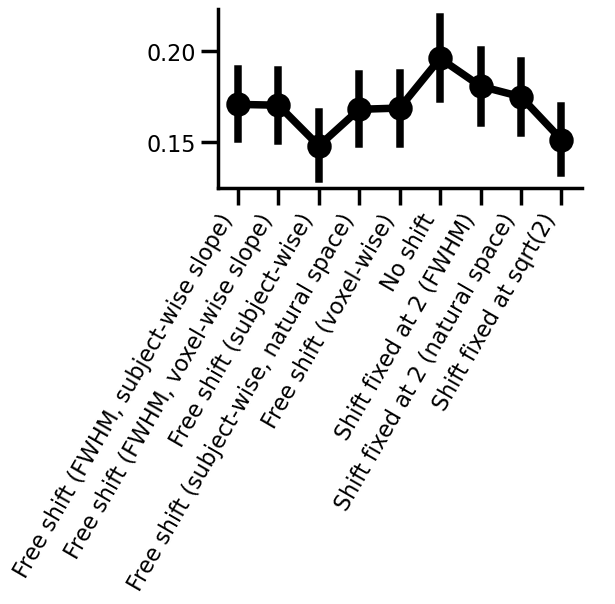

In [150]:
import pingouin as pg
prop_cvr2 = pars.groupby(['model_label', 'subject']).apply(lambda d: ((d[('mu', 'narrow')] > 10) & (d[('mu', 'narrow')] < 25) & (d[('cvr2', 'nan')] > 0.0)).mean()).to_frame('Proportion cvR2 > 0.0')


g = sns.catplot(
    data=prop_cvr2.reset_index(),
    x='model_label',
    y='Proportion cvR2 > 0.0',
    kind='point',
    height=4,
    aspect=1.5,
    color='k',
    errorbar='se',)
    
g.set(xlabel=None, ylabel=None, title=None)

# Set fontsize yticks
for label in g.ax.get_yticklabels():
    label.set_fontsize(16)

# Rotate x-ticks
for label in g.ax.get_xticklabels():
    label.set_rotation(60)
    label.set_horizontalalignment('right')
    label.set_fontsize(16)

# Make figure square
g.fig.set_size_inches(8, 3)

# Set xtick labels custom
# g.ax.set_xticklabels(['No shift', 'Free shift (subject-wise)', 'Free shift (voxel-wise)'], fontsize=16)



# g.savefig(fig_folder / 'dispersion_shift_proportion_cvr2.pdf', bbox_inches='tight')

pg.pairwise_tests(
    prop_cvr2.reset_index(),
    dv='Proportion cvR2 > 0.0',
    within='model_label',
    subject='subject',)

Text(0.5, 1.0, 'Shift ratio (natural space)')

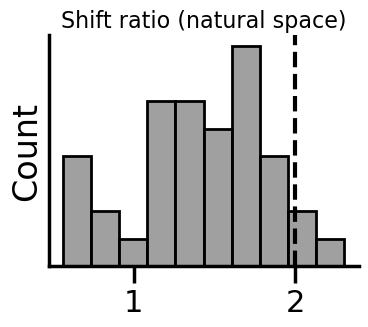

In [121]:
sd_shift_natural = pars_.xs('Free shift (FWHM, subject-wise slope)', level='model_label')['sd']
sd_shift_natural = (sd_shift_natural['wide'] / sd_shift_natural['narrow']).groupby('subject').mean()

sns.histplot(sd_shift_natural, bins=10, color='grey')
plt.gcf().set_size_inches(4, 3)
plt.axvline(2., c='k', ls='--')

sns.despine()
plt.yticks([])

plt.title('Shift ratio (natural space)', fontsize=16)

Text(0.5, 1.0, 'Shift ratio (natural space)')

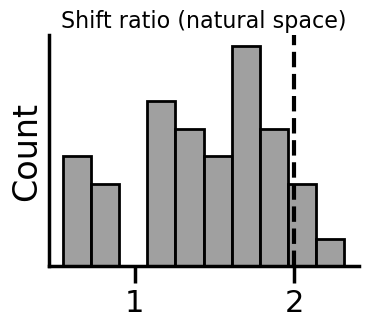

In [122]:
sd_shift_natural = pars_.xs('Free shift (subject-wise, natural space)', level='model_label')['sd']
sd_shift_natural = (sd_shift_natural['wide'] / sd_shift_natural['narrow']).groupby('subject').mean()

sns.histplot(sd_shift_natural, bins=10, color='grey')
plt.gcf().set_size_inches(4, 3)
plt.axvline(2., c='k', ls='--')

sns.despine()
plt.yticks([])

plt.title('Shift ratio (natural space)', fontsize=16)

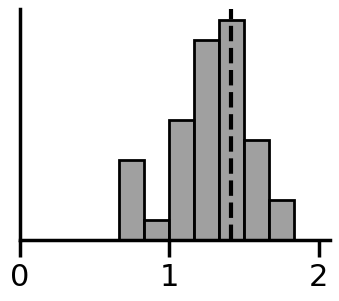

In [123]:
sd_shift = pars_.xs('Free shift (subject-wise)', level='model_label', )['sd']
sd_shift = sd_shift['wide'] / sd_shift['narrow']

ax = sns.histplot(sd_shift.groupby('subject').mean(),
             legend=False, color='grey',
             bins=np.linspace(.5, 2., 10))

sns.despine()

plt.ylabel('')
plt.yticks([])

plt.gcf().set_size_inches(4, 3)

plt.axvline(np.sqrt(2), color='k', linestyle='--', label='Identity line')

plt.xticks([0, 1, 2])

ax.figure.savefig(fig_folder / 'dispersion_shift_sd.pdf', bbox_inches='tight')

In [124]:
import numpy as np

def calculate_std_natural(mode_natural, sigma_log):
    # Calculate mu in log-space
    mu_log = np.log(mode_natural) + sigma_log**2

    # Calculate the variance in natural space
    variance_natural = (np.exp(sigma_log**2) - 1) * np.exp(2 * mu_log + sigma_log**2)

    # Calculate the standard deviation in natural space
    std_natural = np.sqrt(variance_natural)

    return std_natural


pars['std_natural', 'narrow'] = calculate_std_natural(pars['mu'], pars['sd'])['narrow']
pars['std_natural', 'wide'] = calculate_std_natural(pars['mu'], pars['sd'])['wide']

/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: overflow encountered in exp
  result = func(self.values, **kwargs)
/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
/Users/gdehol/mambaforge/envs/neural_priors/lib/python3.9/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: overflow encountered in exp
  result = func(self.values, **kwargs)


In [125]:
pars

parameter                                mu                    sd             \
range                                narrow       wide     narrow       wide   
subject model_label smoothed                                                   
1       0           True     0    10.698851  10.698851   0.128387   0.128387   
                             1    12.097051  12.097051   0.047358   0.047358   
                             2    13.019329  13.019329   0.156827   0.156827   
                             3    15.027272  15.027272   0.071559   0.071559   
                             4    11.410503  11.410503   0.092538   0.092538   
...                                     ...        ...        ...        ...   
41      30          True     689  11.852533  13.705067  18.626127  34.529587   
                             690  21.768723  33.537445   2.311164   2.529497   
                             691  12.083402  14.166803  20.358780  41.180416   
                             692   9.999539   9.999539  10.374187  13.673571   
                             693  11.877099  13.754198  27.304312  54.709736   

parameter                        delta_wide      amplitude            \
range                                narrow wide    narrow      wide   
subject model_label smoothed                                           
1       0           True     0          1.0  1.0  0.287954  0.287954   
                             1          1.0  1.0  0.396764  0.396764   
                             2          1.0  1.0  0.160411  0.160411   
                             3          1.0  1.0  0.305217  0.305217   
                             4          1.0  1.0  0.359884  0.359884   
...                                     ...  ...       ...       ...   
41      30          True     689        2.0  2.0  0.409332  0.409332   
                             690        2.0  2.0  0.157560  0.157560   
                             691        2.0  2.0  0.518958  0.518958   
                             692        2.0  2.0  0.213308  0.213308   
                             693        2.0  2.0  0.571981  0.571981   

parameter                         baseline                  r2      cvr2  \
range                               narrow      wide       nan       nan   
subject model_label smoothed                                               
1       0           True     0   -0.117511 -0.117511  0.007678 -0.018960   
                             1   -0.512096 -0.512096  0.007553 -0.019339   
                             2   -0.514299 -0.514299  0.005133 -0.026036   
                             3   -0.310229 -0.310229  0.014921 -0.021961   
                             4   -0.109330 -0.109330  0.007671 -0.015200   
...                                    ...       ...       ...       ...   
41      30          True     689  0.009243  0.009243  0.024051  0.000432   
                             690  0.270569  0.270569  0.013445  0.002078   
                             691 -0.198287 -0.198287  0.026439  0.015862   
                             692 -0.134283 -0.134283  0.015108 -0.030171   
                             693 -0.426241 -0.426241  0.012497  0.003172   

parameter                          std_natural                
range                                   narrow          wide  
subject model_label smoothed                                  
1       0           True     0    1.413798e+00  1.413798e+00  
                             1    5.751505e-01  5.751505e-01  
                             2    2.131604e+00  2.131604e+00  
                             3    1.085019e+00  1.085019e+00  
                             4    1.071844e+00  1.071844e+00  
...                                        ...           ...  
41      30          True     689           inf           inf  
                             690  9.469763e+05  1.209788e+07  
                             691           inf           inf  
                             692  3.025426e+94   

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_88834/4274451868.py:1: PerformanceWarning: indexing past lexsort depth may impact performance.
  sns.heatmap(pars[pars[('cvr2', 'nan')] > 0.0].unstack('model_label')[('sd', 'narrow')].corr())


<Axes: xlabel='model_label', ylabel='model_label'>

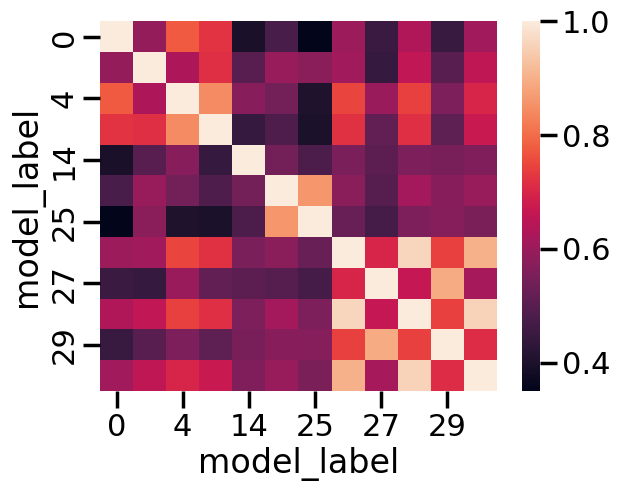

In [126]:
sns.heatmap(pars[pars[('cvr2', 'nan')] > 0.0].unstack('model_label')[('sd', 'narrow')].corr())

In [127]:
tmp = pars.xs('Free shift (voxel-wise)', level='model_label', )

std_scaling = tmp[('std_natural', 'wide')] / tmp[('std_natural', 'narrow')]


sns.distplot(np.clip(std_scaling, 0, 5))

plt.axvline(2, color='k', linestyle='--', label='Identity line')

plt.title('Standard deviation scaling (wide / narrow)\nvoxelwise fits of sigma_log')

KeyError: 'Free shift (voxel-wise)'

In [128]:
tmp = pars.xs('Free shift (subject-wise)', level='model_label', )

std_scaling = tmp[('std_natural', 'wide')] / tmp[('std_natural', 'narrow')]


sns.distplot(np.clip(std_scaling, 0, 5))

plt.axvline(2, color='k', linestyle='--', label='Identity line')

plt.title('Standard deviation scaling (wide / narrow)\nsubject-wise slopes on sigma_log')

KeyError: 'Free shift (subject-wise)'

In [129]:
std_scaling.groupby(['subject']).median().median()

NameError: name 'std_scaling' is not defined

# Estimates

([<matplotlib.axis.XTick at 0x30b1b53d0>,
 [Text(0, 0, '0'), Text(1, 0, '1'), Text(2, 0, '2')])

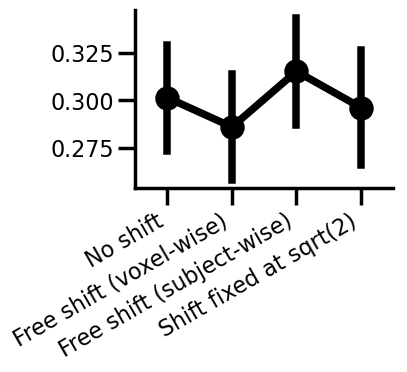

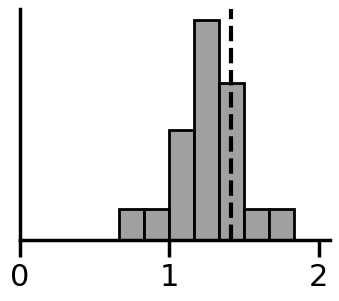

In [ ]:
bids_folder = Path('/data/ds-neuralpriors')
# pars = pd.read_csv(bids_folder / 'derivatives' / 'encoding_models' / 'group_roi-NPCr_desc-groundtruth_parameters.tsv', sep='\t', index_col=[0, 1, 2, 3], header=[0, 1, ])
pars = pd.read_csv(bids_folder / 'derivatives' / 'encoding_models' / 'group_roi-NPCr_desc-responses_parameters.bak2.tsv', sep='\t', index_col=[0, 1, 2, 3], header=[0, 1, ])
pars.index.set_names('subject', level='subject_id', inplace=True)
cvr2_mask = pars[pars[('cvr2', 'nan')] > 0.0]


model_sd_fixed = pars.xs(4, level='model_label', )
model_sd_voxel_free = pars.xs(14, level='model_label', )
model_sd_slope_fixed = pars.xs(15, level='model_label')
# model_sd_slope_fixed_sqrt2 = pars.xs(25, level='model_label')
pars = pd.concat((model_sd_fixed, model_sd_voxel_free, model_sd_slope_fixed, model_sd_slope_fixed_sqrt2), axis=0, keys=['No shift', 'Free shift (voxel-wise)', 'Free shift (subject-wise)',
                                                                                            'Shift fixed at sqrt(2)'], names=['model_label'])

pars_ = pars[pars[('cvr2', 'nan')] > 0.0]
import pingouin as pg
prop_cvr2 = pars.groupby(['model_label', 'subject']).apply(lambda d: (d[('cvr2', 'nan')] > 0.0).mean()).to_frame('Proportion cvR2 > 0.0')


g = sns.catplot(
    data=prop_cvr2.reset_index(),
    x='model_label',
    y='Proportion cvR2 > 0.0',
    kind='point',
    height=4,
    aspect=1.5,
    color='k',
    errorbar='se',
    order=['No shift', 'Free shift (voxel-wise)', 'Free shift (subject-wise)',
           'Shift fixed at sqrt(2)'],
)

g.set(xlabel=None, ylabel=None, title=None)

# Set fontsize yticks
for label in g.ax.get_yticklabels():
    label.set_fontsize(16)

# Rotate x-ticks
for label in g.ax.get_xticklabels():
    label.set_rotation(30)
    label.set_horizontalalignment('right')
    label.set_fontsize(16)

# Make figure square
g.fig.set_size_inches(4, 3)

# Set xtick labels custom
# g.ax.set_xticklabels(['No shift', 'Free shift (subject-wise)', 'Free shift (voxel-wise)'], fontsize=16)



g.savefig(fig_folder / 'dispersion_shift_proportion_cvr2.pdf', bbox_inches='tight')

plt.figure()
pg.pairwise_tests(
    prop_cvr2.reset_index(),
    dv='Proportion cvR2 > 0.0',
    within='model_label',
    subject='subject',)

sd_shift = pars_.xs('Free shift (subject-wise)', level='model_label', )['sd']
sd_shift = sd_shift['wide'] / sd_shift['narrow']

ax = sns.histplot(sd_shift.groupby('subject').mean(),
             legend=False, color='grey',
             bins=np.linspace(.5, 2., 10))

sns.despine()

plt.ylabel('')
plt.yticks([])

plt.gcf().set_size_inches(4, 3)

plt.axvline(np.sqrt(2), color='k', linestyle='--', label='Identity line')

plt.xticks([0, 1, 2])

# ax.figure.savefig(fig_folder / 'dispersion_shift_sd.pdf', bbox_inches='tight')

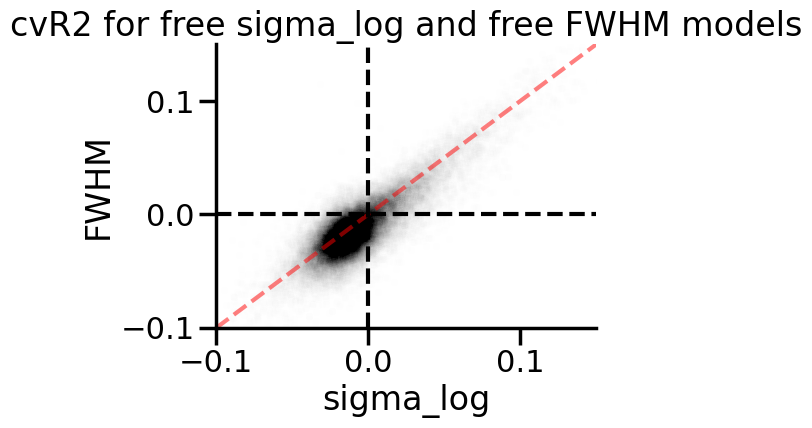

In [131]:
tmp = pd.concat((model_sd_voxel_free, model_fwhm_voxel_free), axis=0, keys=['sigma_log', 'FWHM'], names=['model_label'])

sns.scatterplot(x='sigma_log', y='FWHM', data=tmp[('cvr2', 'nan')].unstack('model_label'),
                legend=False, color='black', s=30, alpha=.005)

plt.axline((0,0), slope=1., c='red', alpha=.5, linestyle='--')

plt.axvline(0, color='k', linestyle='--')
plt.axhline(0, color='k', linestyle='--')

plt.title('cvR2 for free sigma_log and free FWHM models')

plt.xlim(-.1, .15)
plt.ylim(-.1, .15)

sns.despine()
plt.tight_layout()

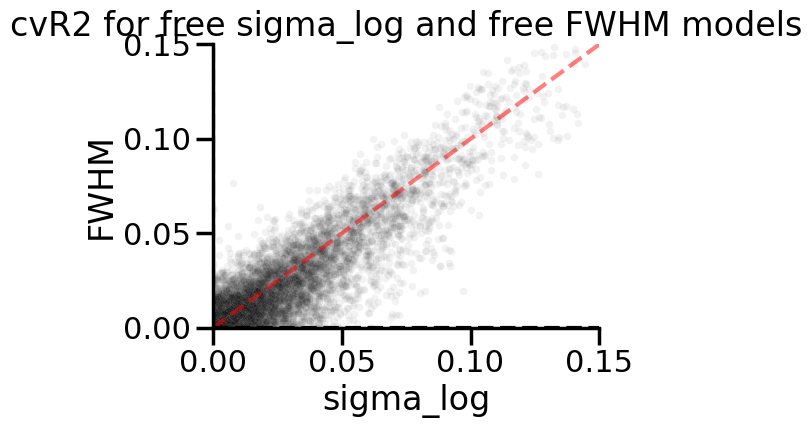

In [132]:
tmp = pd.concat((model_sd_voxel_free, model_fwhm_voxel_free), axis=0, keys=['sigma_log', 'FWHM'], names=['model_label'])

sns.scatterplot(x='sigma_log', y='FWHM', data=tmp[('cvr2', 'nan')].unstack('model_label'),
                legend=False, color='black', s=30, alpha=.05)

plt.axline((0,0), slope=1., c='red', alpha=.5, linestyle='--')

plt.axvline(0, color='k', linestyle='--')
plt.axhline(0, color='k', linestyle='--')

plt.title('cvR2 for free sigma_log and free FWHM models')

plt.xlim(0.0, .15)
plt.ylim(0.0, .15)

sns.despine()
plt.tight_layout()

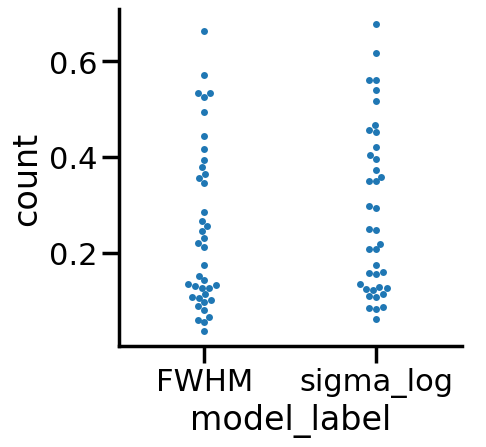

In [133]:
count = (tmp['cvr2'] > 0.0).groupby(['model_label', 'subject']).mean().iloc[:, 0].rename('count')

sns.catplot(x='model_label', y='count', data=count.reset_index(), kind='swarm')

In [134]:
count.groupby(['model_label']).describe()

,count,mean,std,min,25%,50%,75%,max
model_label,,,,,,,,
FWHM,39.0,0.250566,0.171582,0.037815,0.111157,0.211779,0.371980,0.662393
sigma_log,39.0,0.285912,0.174431,0.061625,0.127056,0.247911,0.412359,0.676638
